In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/datasets/kmader/skin-

In [1]:
import pandas as pd
import os
from glob import glob

# 1. Broaden the base directory to the root input folder
base_dir = '/kaggle/input'

# 2. Use a "Super-Search" to find the CSV file anywhere in the input folder
# This will find it whether it's in /datasets/kmader/... or /skin-cancer-mnist...
all_csv_files = glob(os.path.join(base_dir, '**/*.csv'), recursive=True)
metadata_path = [f for f in all_csv_files if 'metadata' in f.lower()][0]

# 3. Load the metadata
df = pd.read_csv(metadata_path)

# 4. Use a "Super-Search" to find all .jpg images in all subfolders
image_paths = glob(os.path.join(base_dir, '**/*.jpg'), recursive=True)

# 5. Create the mapping dictionary
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_paths}

# 6. Map paths to the dataframe
df['path'] = df['image_id'].map(imageid_path_dict.get)

print(f"✅ Success! Metadata Loaded: {len(df)} rows")
print(f"✅ Success! Images Linked: {len(imageid_path_dict)} files")

✅ Success! Metadata Loaded: 10015 rows
✅ Success! Images Linked: 10015 files


. Prepare the Full Data Splits

In [2]:
from sklearn.model_selection import train_test_split

# 1. Use the full cleaned dataframe (all 10,000+ rows)
df_full = df.dropna(subset=['path']).copy()

# 2. Convert labels to strings (required by the Keras Generator)
df_full['label_str'] = df_full['dx'].astype(str)

# 3. Split into Train and Test
train_df, test_df = train_test_split(df_full, test_size=0.2, random_state=42, stratify=df_full['dx'])

print(f"Total training images: {len(train_df)}")
print(f"Total testing images: {len(test_df)}")

Total training images: 8012
Total testing images: 2003


"Real-Time" Normalizing Generators

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. We add rotation, flipping, and zooming to the training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=90,      
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# 2. Test data should NEVER be augmented, only scaled
test_datagen = ImageDataGenerator(rescale=1./255)

# Create the Training Generator 
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="label_str",
    target_size=(124, 124),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

# Create the Testing Generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="label_str",
    target_size=(124, 124),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

2026-05-05 14:15:46.666853: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777990546.877566      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777990546.936081      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777990547.451124      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777990547.451172      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777990547.451175      57 computation_placer.cc:177] computation placer alr

Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


Build the Model

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load the pre-trained MobileNetV2 without the top (classification) layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(124, 124, 3), 
    include_top=False, 
    weights='imagenet'
)

# 2. Freeze the base model (we don't want to change Google's weights yet)
base_model.trainable = False

# 3. Add our own custom "Medical" layers on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3), # Helps prevent the model from memorizing the data
    layers.Dense(7, activation='softmax') # 7 classes for the 7 skin cancer types
])

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/tmp/ipykernel_57/3241493868.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(
I0000 00:00:1777990599.706307      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Add the Class Weights

In [5]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1. Get the actual labels from the training generator
train_labels = train_generator.classes

# 2. Calculate the penalty weights based on frequency
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# 3. Convert to a dictionary that Keras can read
class_weight_dict = dict(enumerate(class_weights))
print("Class Penalty Weights successfully calculated!")
print(class_weight_dict)

Class Penalty Weights successfully calculated!
{0: np.float64(4.368593238822246), 1: np.float64(2.7848453249913105), 2: np.float64(1.3021290427433772), 3: np.float64(12.440993788819876), 4: np.float64(1.2860353130016051), 5: np.float64(0.21338020666879728), 6: np.float64(10.040100250626567)}


Train the Model

In [51]:
# Train the model with the new weights and more epochs
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=test_generator,
    validation_steps=len(test_generator),
    epochs=15,                            # Increased to 15 epochs 
    class_weight=class_weight_dict        # The magic ingredient!
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
 76/251 ━━━━━━━━━━━━━━━━━━━━ 1:38 561ms/step - accuracy: 0.2043 - loss: 2.2431

2026-05-05 07:14:38.366387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 07:14:38.511575: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


251/251 ━━━━━━━━━━━━━━━━━━━━ 185s 703ms/step - accuracy: 0.2734 - loss: 2.0502 - val_accuracy: 0.5632 - val_loss: 1.3635
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 91s 364ms/step - accuracy: 0.4363 - loss: 1.6233 - val_accuracy: 0.4873 - val_loss: 1.4262
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 351ms/step - accuracy: 0.4728 - loss: 1.4964 - val_accuracy: 0.4343 - val_loss: 1.5841
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 348ms/step - accuracy: 0.4686 - loss: 1.4891 - val_accuracy: 0.4598 - val_loss: 1.5155
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 347ms/step - accuracy: 0.4835 - loss: 1.4106 - val_accuracy: 0.4548 - val_loss: 1.5175
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 345ms/step - accuracy: 0.4839 - loss: 1.3909 - val_accuracy: 0.5372 - val_loss: 1.3168
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 345ms/step - accuracy: 0.5179 - loss: 1.3341 - val_accuracy: 0.4583 - val_loss: 1.4670
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 86s 344ms/step - accuracy: 0.4936 - loss: 1.3769 - va

Fine-Tuning

In [52]:
from tensorflow.keras.optimizers import Adam

# 1. Unfreeze the base model so it can learn microscopic skin textures
base_model.trainable = True

# 2. Re-compile the model with a VERY LOW learning rate 
# (We use 1e-5 so we don't accidentally wreck the pre-trained weights)
model.compile(
    optimizer=Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model unfrozen and ready for fine-tuning!")

# 3. Train it for another 10 epochs to make it a specialist
history_finetune = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=test_generator,
    validation_steps=len(test_generator),
    epochs=10,
    class_weight=class_weight_dict # We must keep using our magic weights!
)

Model unfrozen and ready for fine-tuning!
Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 168s 493ms/step - accuracy: 0.4354 - loss: 2.8429 - val_accuracy: 0.5507 - val_loss: 1.3120
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 90s 358ms/step - accuracy: 0.3642 - loss: 1.9634 - val_accuracy: 0.5462 - val_loss: 1.3071
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 90s 357ms/step - accuracy: 0.3919 - loss: 1.6259 - val_accuracy: 0.4868 - val_loss: 1.3846
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 352ms/step - accuracy: 0.3973 - loss: 1.5706 - val_accuracy: 0.5077 - val_loss: 1.4055
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 352ms/step - accuracy: 0.4200 - loss: 1.5607 - val_accuracy: 0.5252 - val_loss: 1.3510
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 86s 344ms/step - accuracy: 0.4641 - loss: 1.3820 - val_accuracy: 0.5657 - val_loss: 1.2789
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 86s 343ms/step - accuracy: 0.4724 - loss: 1.2973 - val_accuracy: 0.5956 - val_loss: 1.2153
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 

Save  Model

In [6]:
model.save('skin_cancer_model.h5')
print("✅ Model saved successfully!")

✅ Model saved successfully!


Confusion Matrix

Classification Report

63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 233ms/step


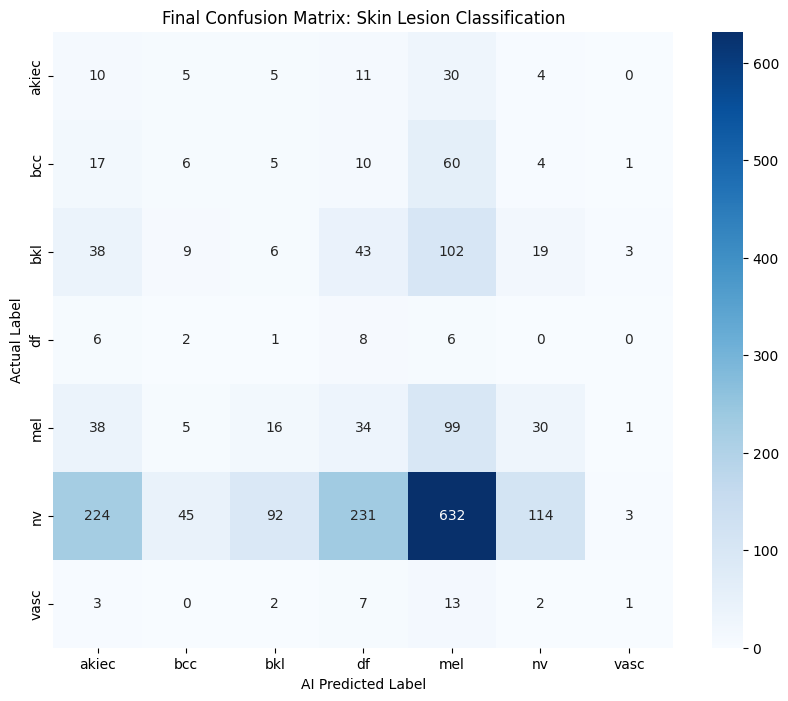

              precision    recall  f1-score   support

       akiec       0.03      0.15      0.05        65
         bcc       0.08      0.06      0.07       103
         bkl       0.05      0.03      0.03       220
          df       0.02      0.35      0.04        23
         mel       0.11      0.44      0.17       223
          nv       0.66      0.09      0.15      1341
        vasc       0.11      0.04      0.05        28

    accuracy                           0.12      2003
   macro avg       0.15      0.16      0.08      2003
weighted avg       0.47      0.12      0.13      2003



In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get predictions for the entire test set
test_generator.reset() # Ensure we start from the first image
Y_pred = model.predict(test_generator, steps=len(test_generator))
y_pred = np.argmax(Y_pred, axis=1)

# 2. Get the actual labels
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Final Confusion Matrix: Skin Lesion Classification')
plt.ylabel('Actual Label')
plt.xlabel('AI Predicted Label')
plt.show()

# 5. Print the text-based report (Precision, Recall, F1-Score)
print(classification_report(y_true, y_pred, target_names=class_names))

ALL IN ONE-It includes the RANDOM SAMPLER,THE TOP-3 CHART, and THE CORRECTED GRAD-CAM LOGIC all in one place.

/tmp/ipykernel_57/2704954442.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = colormap_module.get_cmap("jet")


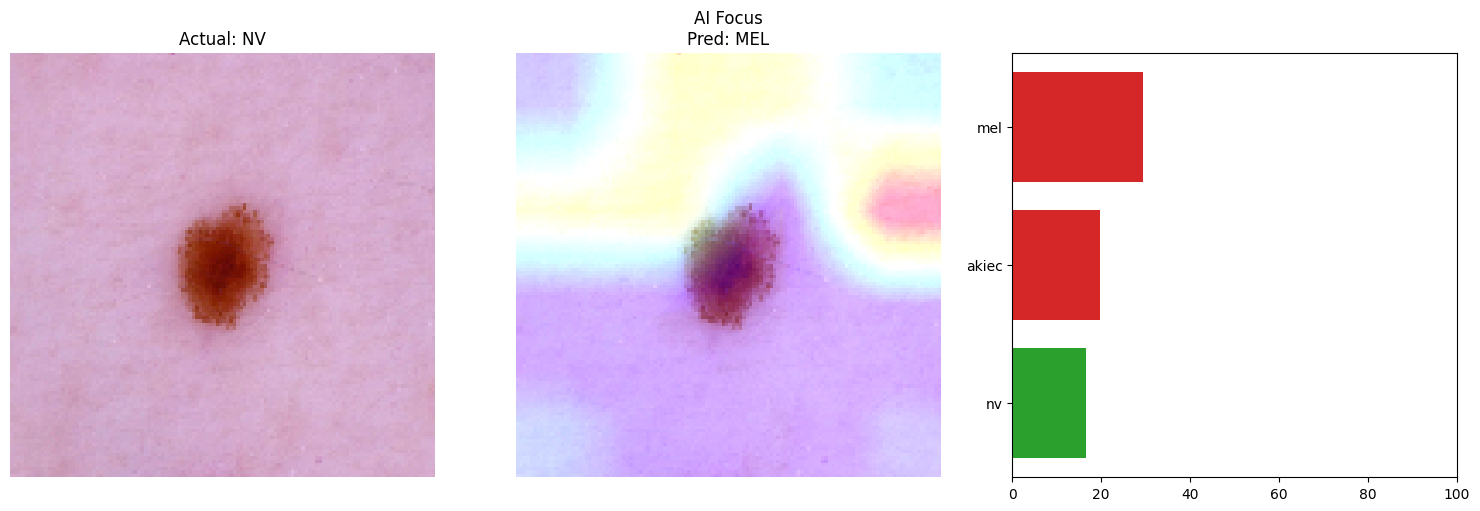

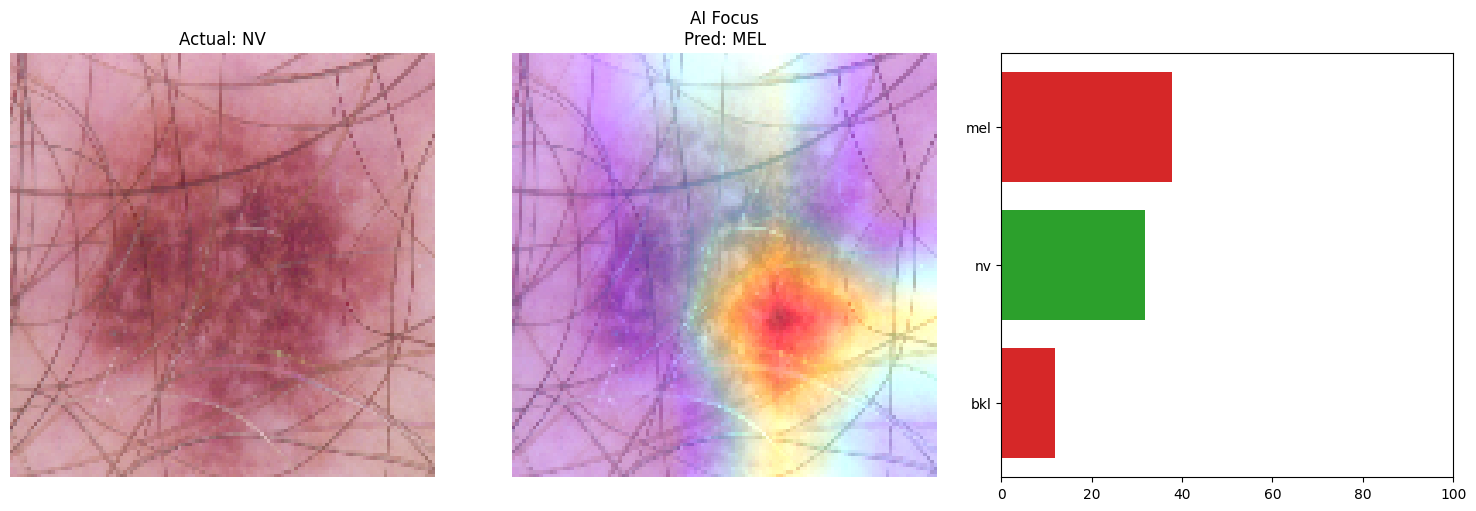

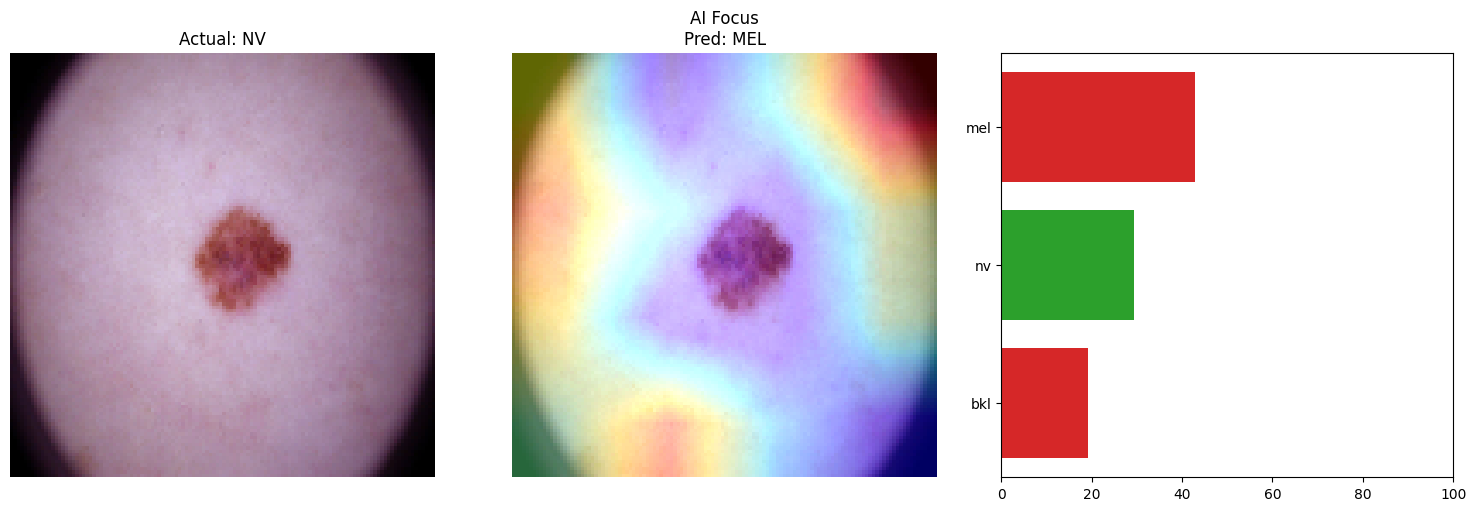

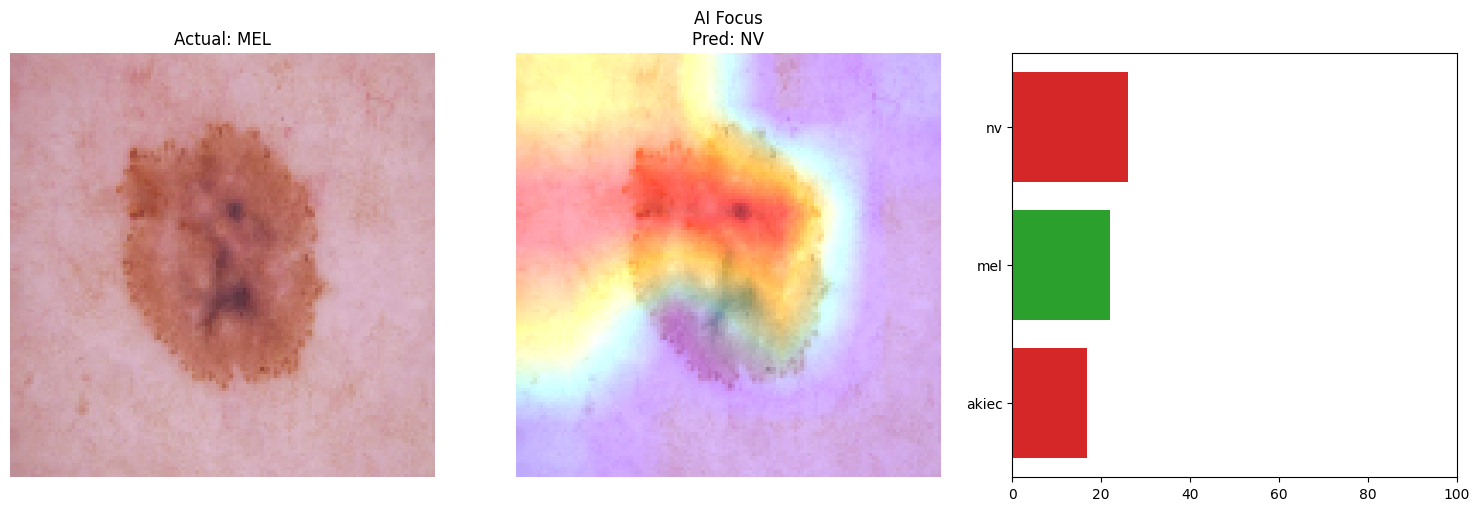

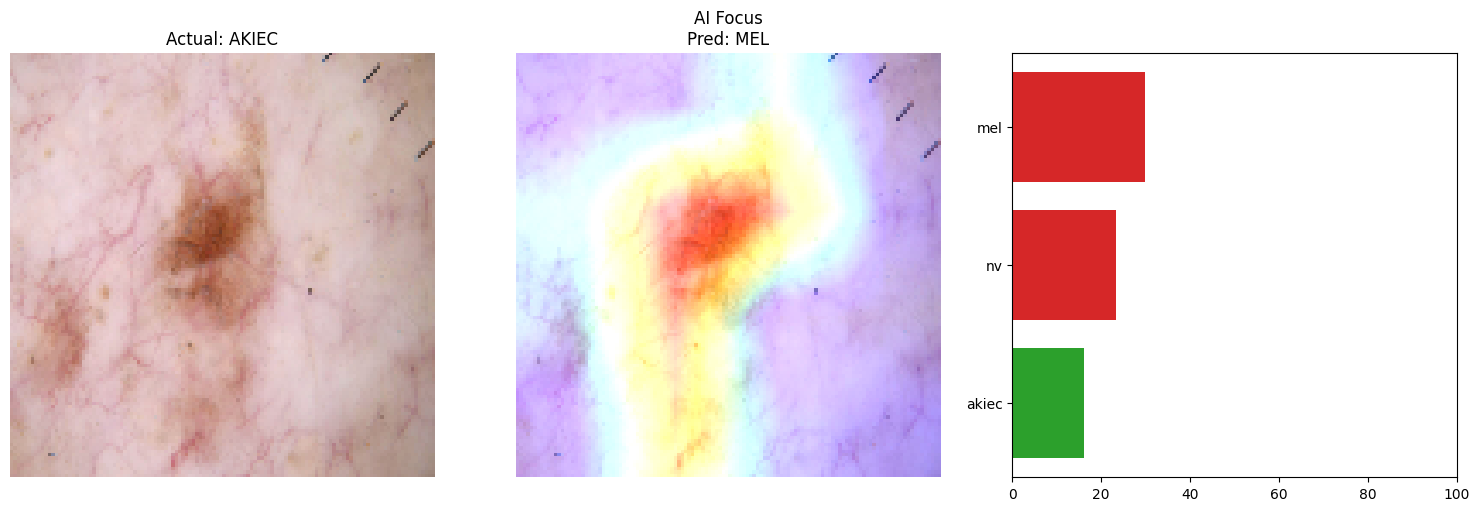

In [18]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as colormap_module
import cv2
import numpy as np
import tensorflow as tf

# 1. Setup Output
output_folder = '/kaggle/working/final_capstone_reports'
os.makedirs(output_folder, exist_ok=True)

# 2. Corrected Grad-CAM Function (Fixed Layer Names)
def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Target the base MobileNetV2 block
    base_model = model.get_layer('mobilenetv2_1.00_224')
    
    grad_model = tf.keras.models.Model(
        [base_model.inputs], 
        [base_model.get_layer(last_conv_layer_name).output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output = grad_model(img_array)
        
        # Using exact names from your error log: global_average_pooling2d, dropout, dense
        x = model.get_layer('global_average_pooling2d')(last_conv_layer_output)
        x = model.get_layer('dropout')(x)
        preds = model.get_layer('dense')(x)
        
        class_channel = preds[:, tf.argmax(preds[0])]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# 3. Final Reporting Pipeline
def final_capstone_pipeline(model, dataframe, num_samples=5):
    class_labels = list(train_generator.class_indices.keys())
    samples = dataframe.sample(num_samples)
    
    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = row['path']
        true_label = row.get('dx', 'unknown')
        
        # Preprocess
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_input = cv2.resize(img, (124, 124))
        img_array = np.expand_dims(img_input, axis=0).astype('float32') / 255.0

        # Predict
        preds = model.predict(img_array, verbose=0)[0]
        top_3_idx = preds.argsort()[-3:][::-1]
        pred_label = class_labels[top_3_idx[0]]

        # Grad-CAM Logic
        heatmap = get_gradcam_heatmap(img_array, model, 'out_relu') 
        heatmap = cv2.resize(heatmap, (124, 124))
        jet = colormap_module.get_cmap("jet")
        jet_colors = jet(np.arange(256))[:, :3]
        jet_heatmap = jet_colors[(heatmap * 255).astype('uint8')]
        superimposed = (jet_heatmap * 0.4) + (img_input / 255.0)
        superimposed = np.clip(superimposed, 0, 1)

        # Create Plot
        fig = plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1).imshow(img_input)
        plt.title(f"Actual: {true_label.upper()}")
        plt.axis('off')
        
        plt.subplot(1, 3, 2).imshow(superimposed)
        plt.title(f"AI Focus\nPred: {pred_label.upper()}")
        plt.axis('off')
        
        ax3 = plt.subplot(1, 3, 3)
        colors = ['#2ca02c' if class_labels[idx] == true_label else '#d62728' for idx in top_3_idx]
        ax3.barh([class_labels[idx] for idx in top_3_idx], [preds[idx]*100 for idx in top_3_idx], color=colors)
        ax3.set_xlim(0, 100)
        ax3.invert_yaxis()

        plt.tight_layout()
        plt.savefig(f"{output_folder}/final_sample_{i+1}.png", dpi=300)
        plt.show()

# 4. Run it
final_capstone_pipeline(model, test_df, num_samples=5)

🔴 Red/Yellow (Hot): These are the specific areas the AI "looked at" most intensely to make its diagnosis.

🔵 Blue/Purple (Cold): These are areas the AI ignored

SAVE IMAGES 

🚀 Starting export of 10 medical reports to: /kaggle/working/final_report_20260505_142719


/tmp/ipykernel_57/1533003505.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = colormap_module.get_cmap("jet")


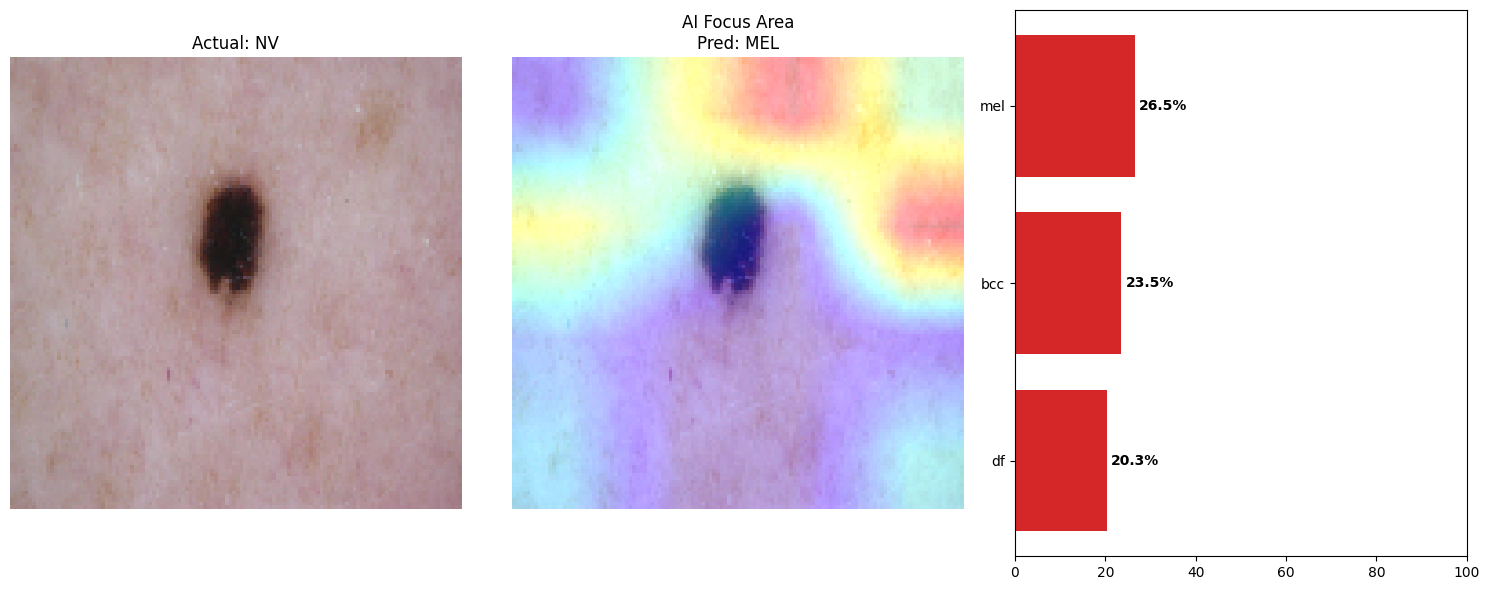

✅ Saved report to: /kaggle/working/final_report_20260505_142719/report_sample_1.png


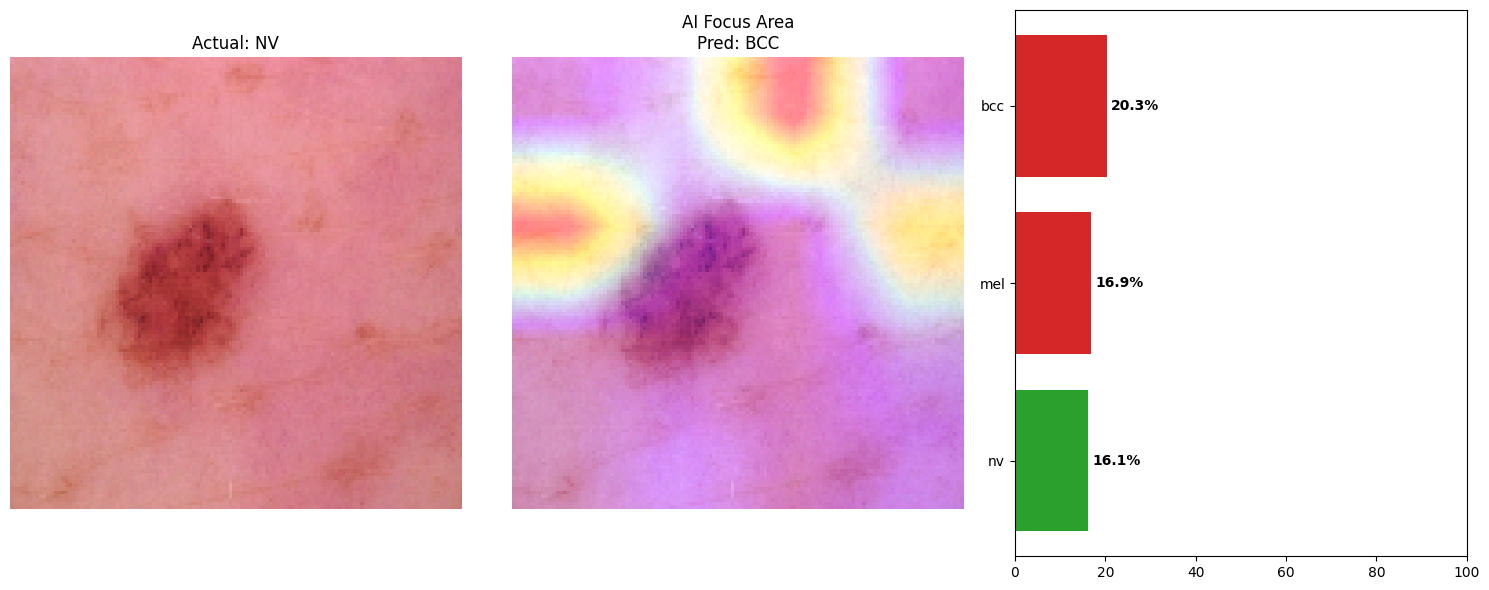

✅ Saved report to: /kaggle/working/final_report_20260505_142719/report_sample_2.png


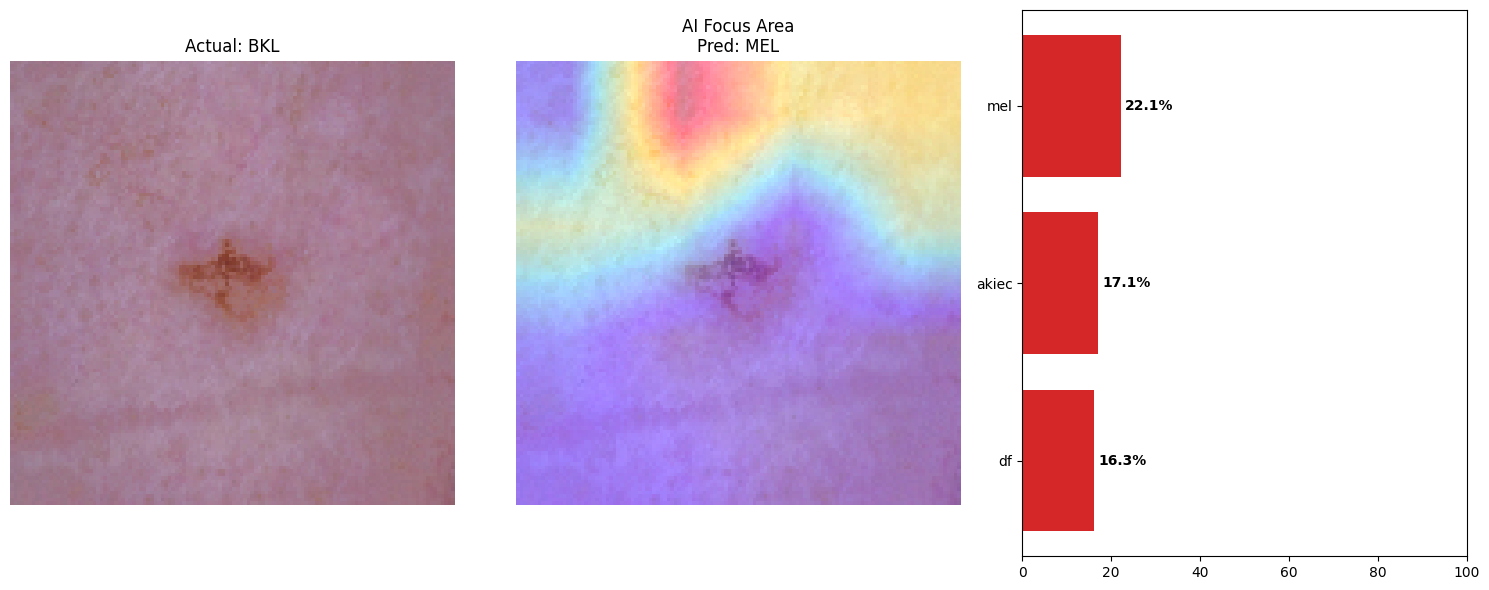

✅ Saved report to: /kaggle/working/final_report_20260505_142719/report_sample_3.png


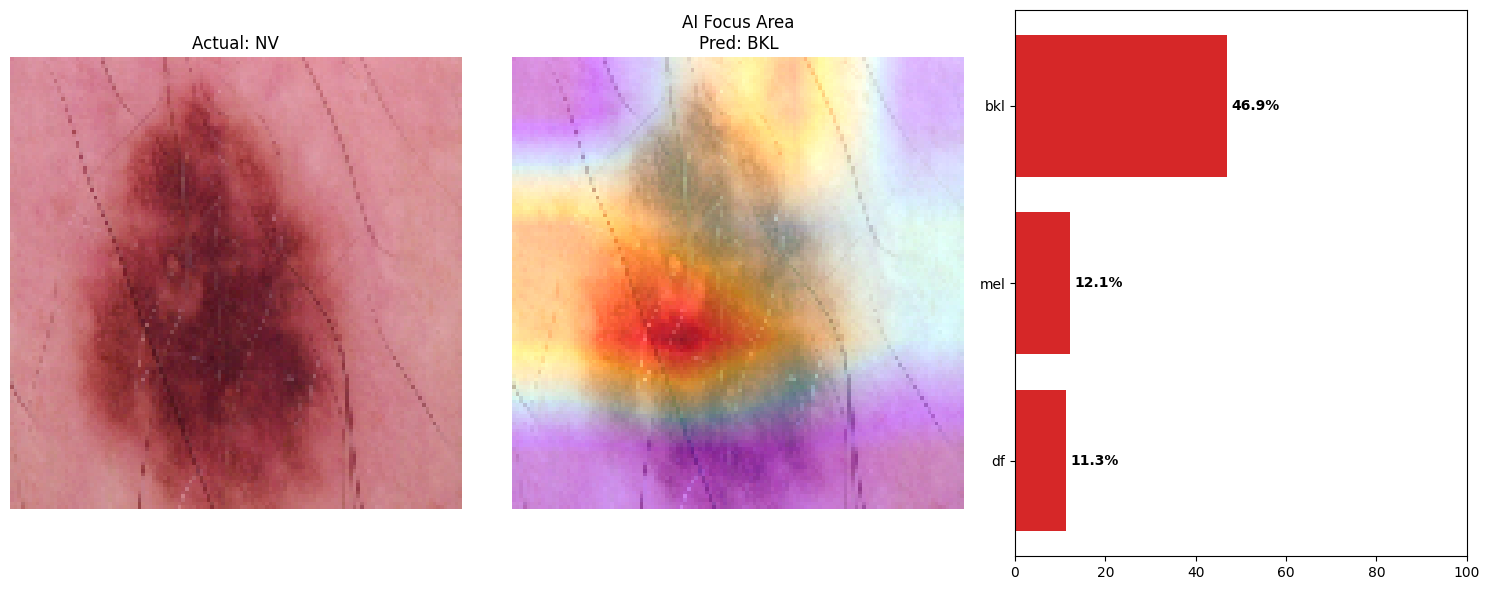

✅ Saved report to: /kaggle/working/final_report_20260505_142719/report_sample_4.png


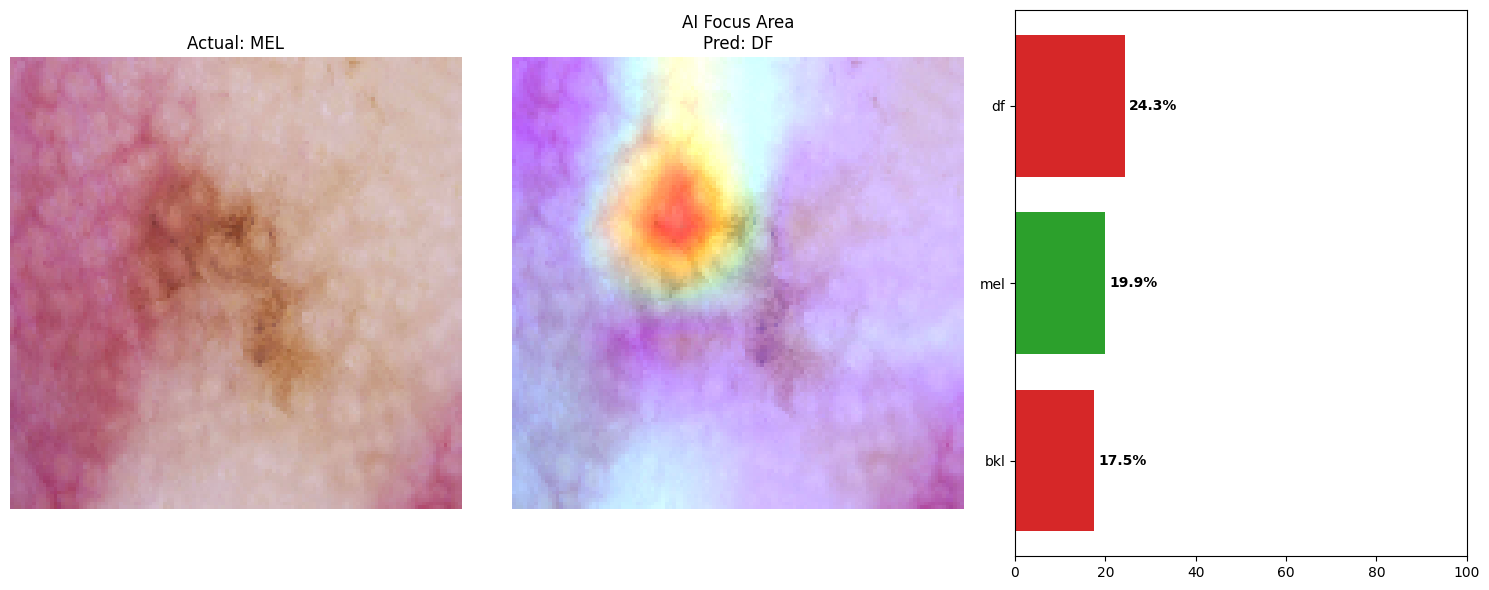

✅ Saved report to: /kaggle/working/final_report_20260505_142719/report_sample_5.png


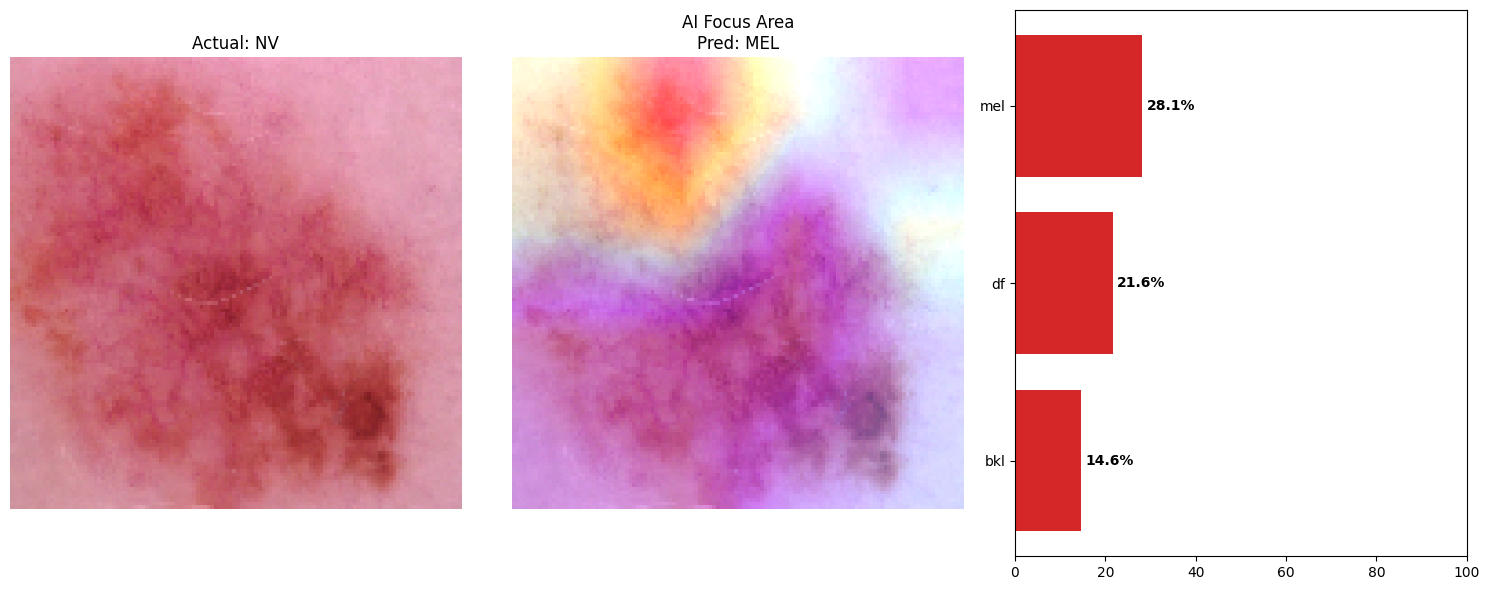

✅ Saved report to: /kaggle/working/final_report_20260505_142719/report_sample_6.png


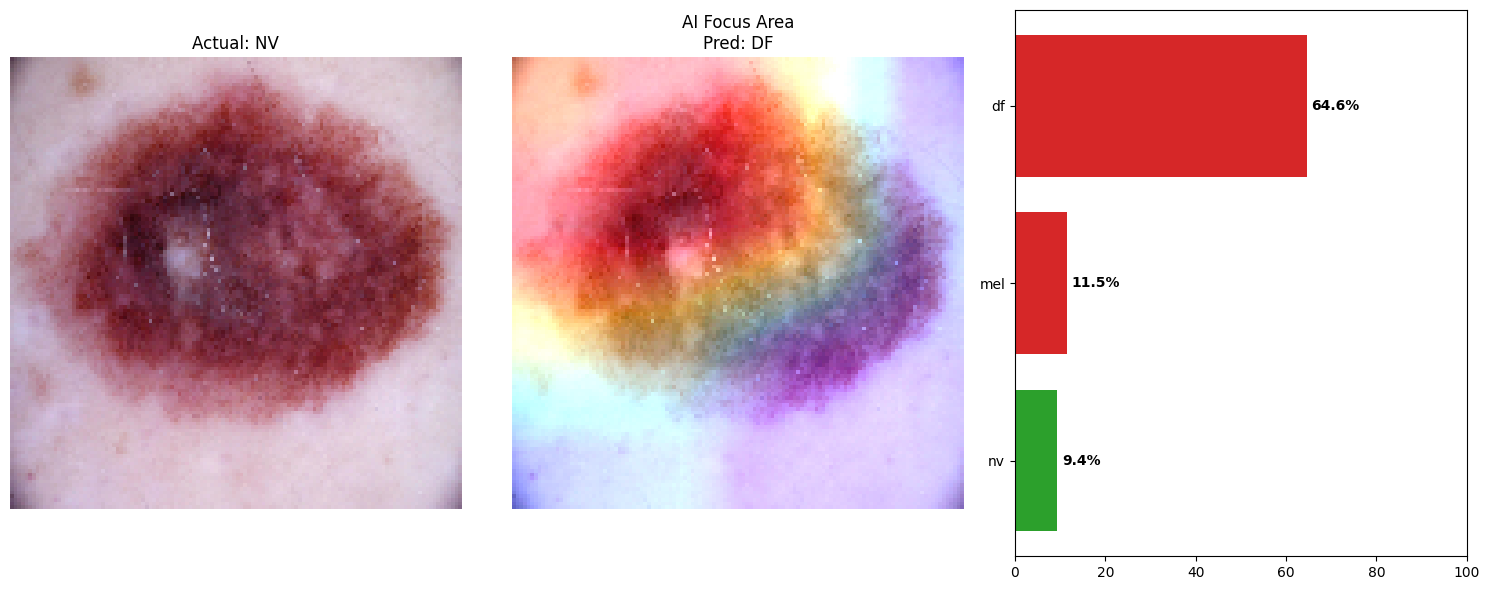

✅ Saved report to: /kaggle/working/final_report_20260505_142719/report_sample_7.png


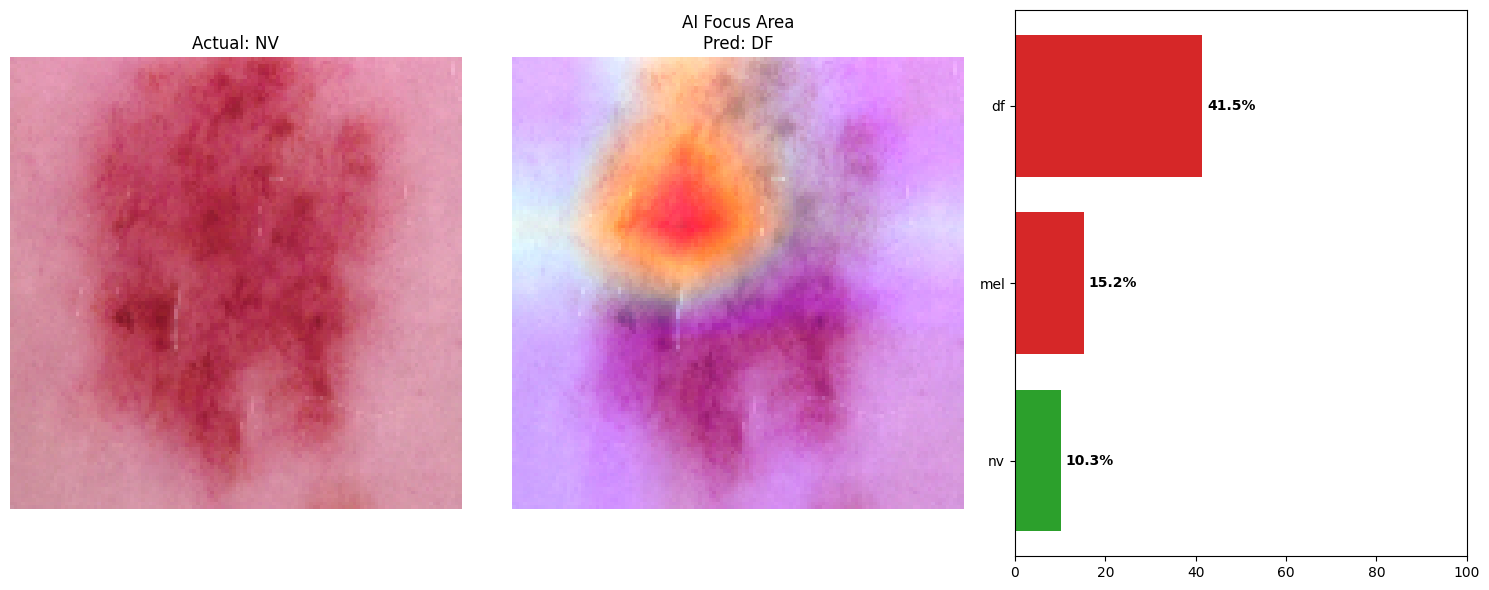

✅ Saved report to: /kaggle/working/final_report_20260505_142719/report_sample_8.png


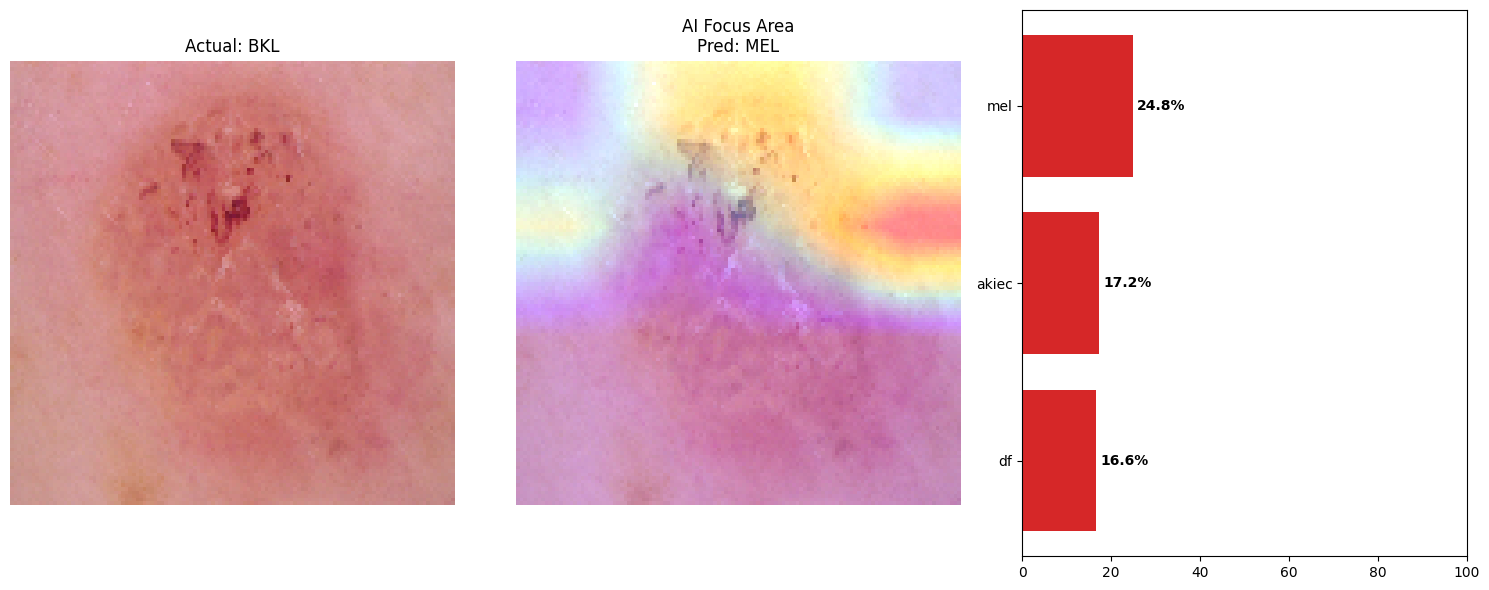

✅ Saved report to: /kaggle/working/final_report_20260505_142719/report_sample_9.png


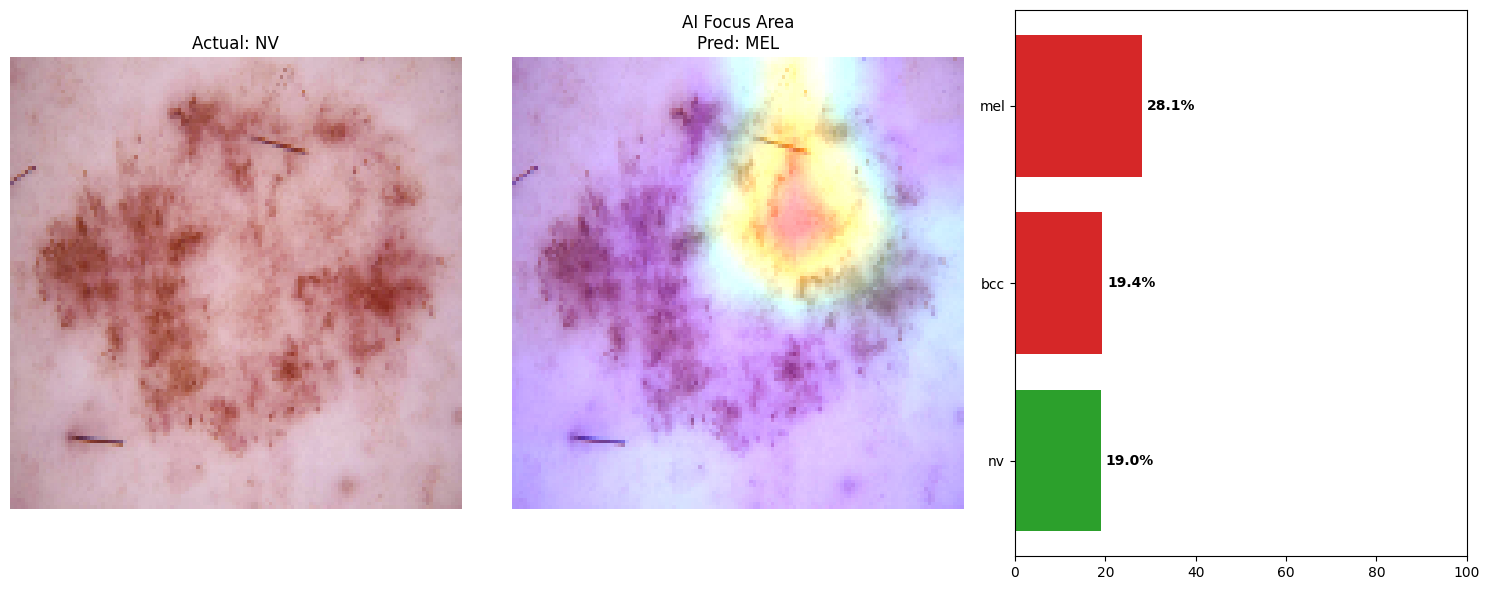

✅ Saved report to: /kaggle/working/final_report_20260505_142719/report_sample_10.png

✅ EXPORT SUCCESSFUL
Total Images Saved: 10
Location: /kaggle/working/final_report_20260505_142719
  - report_sample_1.png
  - report_sample_10.png
  - report_sample_2.png
  - report_sample_3.png
  - report_sample_4.png
  - report_sample_5.png
  - report_sample_6.png
  - report_sample_7.png
  - report_sample_8.png
  - report_sample_9.png


In [17]:
import os
from datetime import datetime

# 1. Create a specialized folder for the final export
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
final_save_dir = f'/kaggle/working/final_report_{timestamp}'
os.makedirs(final_save_dir, exist_ok=True)

# 2. Function to loop and save images specifically
def export_medical_reports(model, dataframe, num_to_save=5):
    print(f"🚀 Starting export of {num_to_save} medical reports to: {final_save_dir}")
    
    # We call your existing pipeline but ensure it saves to our new directory
    # Note: Ensure 'output_folder' inside your pipeline function 
    # uses the 'final_save_dir' variable defined here.
    
    global output_folder # Tell the function to use our new path
    output_folder = final_save_dir
    
    final_capstone_pipeline(model, dataframe, num_samples=num_to_save)
    
    # 3. Final summary
    files_created = os.listdir(final_save_dir)
    print("\n" + "="*30)
    print(f"✅ EXPORT SUCCESSFUL")
    print(f"Total Images Saved: {len(files_created)}")
    print(f"Location: {final_save_dir}")
    print("="*30)
    for f in sorted(files_created):
        print(f"  - {f}")

# 4. Run the export
export_medical_reports(model, test_df, num_to_save=10) # Change 10 to however many you want

ui interface

In [19]:
import gradio as gr
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.cm as colormap_module

# 1. Define the Prediction + Heatmap function for Gradio
def analyze_skin_lesion(input_img):
    # Preprocess image for MobileNetV2
    img_resized = cv2.resize(input_img, (124, 124))
    img_array = np.expand_dims(img_resized, axis=0).astype('float32') / 255.0

    # Get Prediction
    preds = model.predict(img_array, verbose=0)[0]
    class_labels = list(train_generator.class_indices.keys())
    
    # Create Results Dictionary for Gradio Label component
    results = {class_labels[i]: float(preds[i]) for i in range(len(class_labels))}

    # Generate Grad-CAM Heatmap
    # Using exact layer names from your model: global_average_pooling2d, dropout, dense
    heatmap = get_gradcam_heatmap(img_array, model, 'out_relu')
    heatmap_resized = cv2.resize(heatmap, (124, 124))
    
    # Apply Colormap
    jet = colormap_module.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[(heatmap_resized * 255).astype('uint8')]
    
    # Superimpose
    superimposed = (jet_heatmap * 0.4) + (img_resized / 255.0)
    superimposed = np.clip(superimposed, 0, 1)

    return results, superimposed

# 2. Build the Gradio UI
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🩺 Skin Lesion AI Diagnostic Portal")
    gr.Markdown("### Upload a clinical image to see the AI diagnosis and 'Focus Area' heatmap.")
    
    with gr.Row():
        with gr.Column():
            input_image = gr.Image(label="Upload Skin Image")
            submit_btn = gr.Button("Run Analysis", variant="primary")
        
        with gr.Column():
            output_label = gr.Label(num_top_classes=3, label="Top Diagnoses")
            output_heatmap = gr.Image(label="AI Focus Area (Explainable AI)")

    submit_btn.click(
        fn=analyze_skin_lesion, 
        inputs=input_image, 
        outputs=[output_label, output_heatmap]
    )
    
    gr.Markdown("---")
    gr.Markdown("**Disclaimer:** This is an AI research tool. Always consult a certified dermatologist for medical advice.")

# 3. Launch the App
demo.launch(share=True)

/tmp/ipykernel_57/705089974.py:37: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://9c6a3f573f5ab38d5f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 124, 124, 3))
  warnings.warn(msg)
/tmp/ipykernel_57/705089974.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = colormap_module.get_cmap("jet")
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 124, 124, 3))
  warnings.warn(msg)
/tmp/ipykernel_57/705089974.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.c